In [ ]:
#Level2:
#Task1:
#Determine the percentage of restaurants that offer table booking and online delivery:

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Data_Cognifyz.csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
df.shape

(9551, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [9]:

# Calculate percentage
table_booking_pct = (df['has_table_booking'].value_counts(normalize=True) * 100)
online_delivery_pct = (df['has_online_delivery'].value_counts(normalize=True) * 100)

print("Percentage of Restaurants Offering Table Booking:")
print(table_booking_pct)

print("\nPercentage of Restaurants Offering Online Delivery:")
print(online_delivery_pct)

Percentage of Restaurants Offering Table Booking:
has_table_booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

Percentage of Restaurants Offering Online Delivery:
has_online_delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


In [10]:
table_booking_yes = (df['has_table_booking'] == 'Yes').mean() * 100
online_delivery_yes = (df['has_online_delivery'] == 'Yes').mean() * 100

print(f"Table Booking Offered: {table_booking_yes:.2f}%")
print(f"Online Delivery Offered: {online_delivery_yes:.2f}%")

Table Booking Offered: 12.12%
Online Delivery Offered: 25.66%


In [ ]:
#Compare the average ratings of restaurants with table booking and those without:

In [11]:
# Ensure rating column is numeric
df['aggregate_rating'] = pd.to_numeric(df['aggregate_rating'], errors='coerce')

# Group by table booking
rating_comparison = df.groupby('has_table_booking')['aggregate_rating'].mean()

print("Average Ratings Comparison:")
print(rating_comparison)

Average Ratings Comparison:
has_table_booking
No     2.559359
Yes    3.441969
Name: aggregate_rating, dtype: float64


In [ ]:
#Analyze the availability of online delivery among restaurants with different price ranges:

In [12]:
# Check price range distribution
print(df['price_range'].value_counts())

# Online delivery by price range
delivery_by_price = pd.crosstab(df['price_range'], 
                                df['has_online_delivery'], 
                                normalize='index') * 100

print("Online Delivery Availability by Price Range (%):")
print(delivery_by_price)

price_range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64
Online Delivery Availability by Price Range (%):
has_online_delivery         No        Yes
price_range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


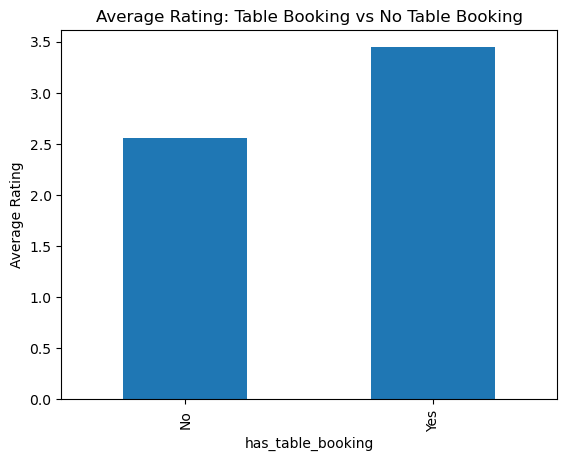

In [13]:
rating_comparison.plot(kind='bar')
plt.title("Average Rating: Table Booking vs No Table Booking")
plt.ylabel("Average Rating")
plt.show()

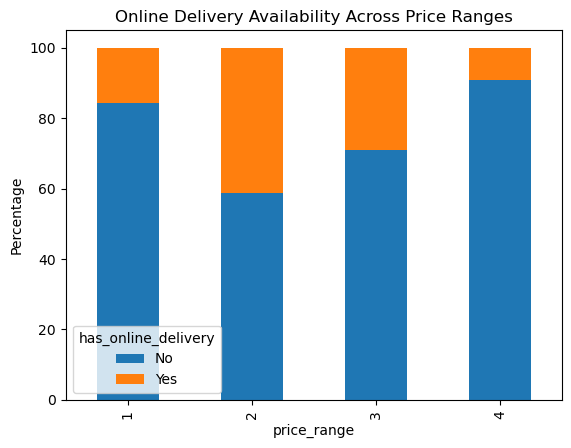

In [14]:
delivery_by_price.plot(kind='bar', stacked=True)
plt.title("Online Delivery Availability Across Price Ranges")
plt.ylabel("Percentage")
plt.show()

In [15]:
#Task 2:
#Price Range Analysis:
#Determine the most common price range among all the restaurants:

In [16]:
# Count price range frequency
price_counts = df['price_range'].value_counts()

print("Most Common Price Range:")
print(price_counts)

# Identify the most common one
most_common_price = price_counts.idxmax()
print(f"\nMost Common Price Range: {most_common_price}")

Most Common Price Range:
price_range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Most Common Price Range: 1


In [17]:
#Calculate the average rating for each price range:

In [18]:
# Ensure rating column is numeric
df['aggregate_rating'] = pd.to_numeric(df['aggregate_rating'], errors='coerce')

# Calculate average rating by price range
avg_rating_price = df.groupby('price_range')['aggregate_rating'].mean().sort_values(ascending=False)

print("\nAverage Rating by Price Range:")
print(avg_rating_price)


Average Rating by Price Range:
price_range
4    3.817918
3    3.683381
2    2.941054
1    1.999887
Name: aggregate_rating, dtype: float64


In [19]:
 # Identify the color that represents the highest average rating among different price ranges:

In [20]:
# Group by price range and rating color
color_rating = df.groupby(['price_range', 'rating_color'])['aggregate_rating'].mean().reset_index()

# Find highest average rating overall
highest_rating_row = color_rating.loc[color_rating['aggregate_rating'].idxmax()]

print("\nColor Representing Highest Average Rating:")
print(highest_rating_row)


Color Representing Highest Average Rating:
price_range                  4
rating_color        Dark Green
aggregate_rating      4.709459
Name: 18, dtype: object


In [21]:
top_color = df.groupby('rating_color')['aggregate_rating'].mean().idxmax()
print(f"\nColor with Highest Average Rating: {top_color}")


Color with Highest Average Rating: Dark Green


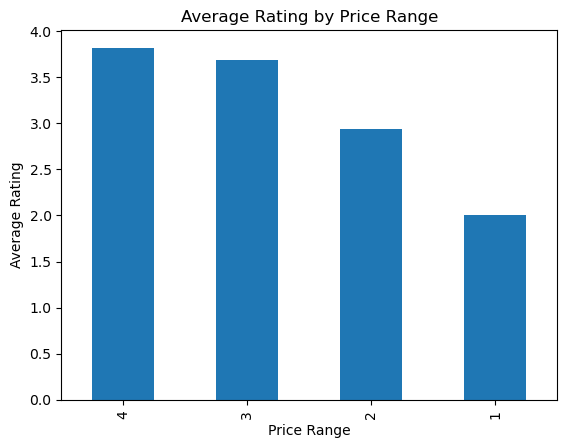

In [22]:
avg_rating_price.plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.ylabel("Average Rating")
plt.xlabel("Price Range")
plt.show()

In [23]:
#Task 3
#Task: Feature Engineering
#Extract additional features from the existingcolumns, such as the length of the restaurant name or address:

In [24]:
df['restaurant_name_length'] = df['restaurant_name'].astype(str).apply(len)

In [25]:
df['restaurant_name_word_count'] = df['restaurant_name'].astype(str).apply(lambda x: len(x.split()))

In [26]:
df['address_length'] = df['address'].astype(str).apply(len)

In [27]:
df['address_word_count'] = df['address'].astype(str).apply(lambda x: len(x.split()))

In [28]:
df['has_table_booking_encoded'] = df['has_table_booking'].map({'Yes': 1, 'No': 0})

In [29]:
df['has_online_delivery_encoded'] = df['has_online_delivery'].map({'Yes': 1, 'No': 0})

In [30]:
df['price_range_encoded'] = pd.factorize(df['price_range'])[0]

In [31]:
df = pd.get_dummies(df, columns=['rating_color'], drop_first=True)

In [32]:
new_features = [
    'restaurant_name_length',
    'restaurant_name_word_count',
    'address_length',
    'address_word_count',
    'has_table_booking_encoded',
    'has_online_delivery_encoded'
]

print(df[new_features].head())

   restaurant_name_length  restaurant_name_word_count  address_length  \
0                      16                           3              71   
1                      16                           2              67   
2                      22                           4              56   
3                       4                           1              70   
4                      11                           2              64   

   address_word_count  has_table_booking_encoded  has_online_delivery_encoded  
0                  10                          1                            0  
1                  10                          1                            0  
2                   8                          1                            0  
3                  10                          0                            0  
4                   9                          1                            0  


In [33]:
print(df[new_features].isnull().sum())

restaurant_name_length         0
restaurant_name_word_count     0
address_length                 0
address_word_count             0
has_table_booking_encoded      0
has_online_delivery_encoded    0
dtype: int64


In [35]:
df.fillna(0, inplace=True)